# Using a Pre-trained ViT for Image Classification

In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch

model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

model.eval()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

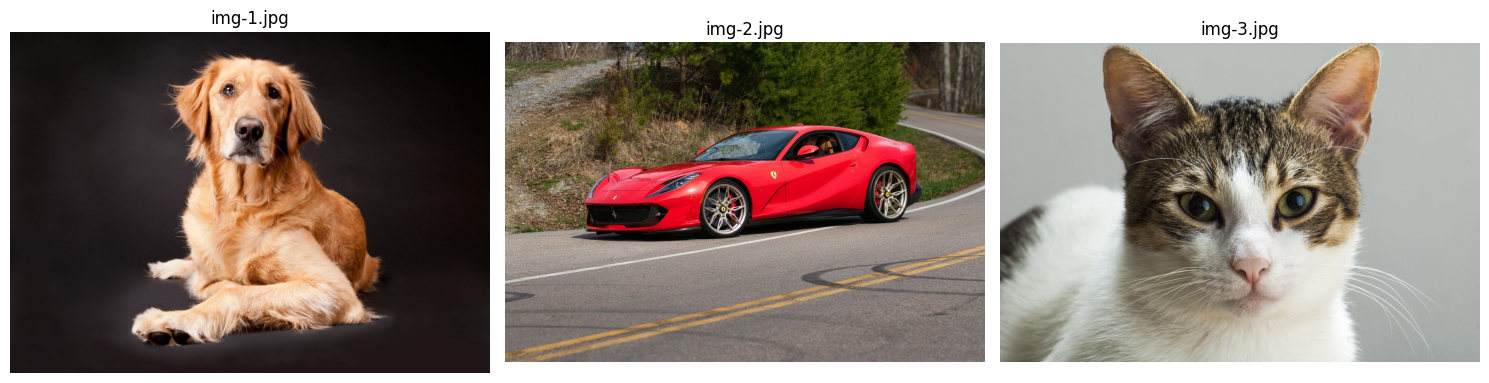

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_paths = [
    "img-1.jpg",
    "img-2.jpg",
    "img-3.jpg"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, path in zip(axes, image_paths):
    image = Image.open(path).convert("RGB")

    ax.imshow(image)
    ax.set_title(path.split("/")[-1])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for path in image_paths:
    image = Image.open(path)
    print(f"{path}: {image.size}")

img-1.jpg: (2048, 1457)
img-2.jpg: (3000, 2000)
img-3.jpg: (2048, 1362)


In [ ]:
from PIL import Image

images = [
    Image.open(f"/content/img-{i}.jpg").convert("RGB")
    for i in range(1, 4)
]

inputs = processor(
    images=images,
    return_tensors="pt"
)

print(inputs["pixel_values"].shape)

torch.Size([3, 3, 224, 224])


In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

probabilities = torch.softmax(outputs.logits, dim=-1)
predicted_classes = outputs.logits.argmax(dim=-1)

for i, class_idx in enumerate(predicted_classes):
    idx = class_idx.item()
    label = model.config.id2label[idx]
    confidence = probabilities[i, idx].item()

    print(
        f"Image {i+1}: {label} "
        f"({confidence:.2%})"
    )

Image 1: golden retriever (98.33%)
Image 2: sports car, sport car (86.27%)
Image 3: Egyptian cat (57.85%)



Visualizing Patch Attention

In [ ]:
model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    attn_implementation="eager"
)

model.eval()

In [ ]:
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

attentions = outputs.attentions
print(f"Number of layers: {len(attentions)}")
print(f"Shape of one layer's attention: {attentions[0].shape}")

Number of layers: 12
Shape of one layer's attention: torch.Size([3, 12, 197, 197])


In [ ]:
import numpy as np

final_layer_attn = attentions[-1]
avg_attn = final_layer_attn.mean(dim=1)
cls_attn = avg_attn[:, 0, 1:]

print(f"CLS attention shape: {cls_attn.shape}")

# Reshape into 14x14 grid per image
grid_size = int(cls_attn.shape[-1] ** 0.5)  # 14
attn_maps = cls_attn.reshape(cls_attn.shape[0], grid_size, grid_size)
print(f"Attention map shape per image: {attn_maps.shape}")

CLS attention shape: torch.Size([3, 196])
Attention map shape per image: torch.Size([3, 14, 14])


Final Layer


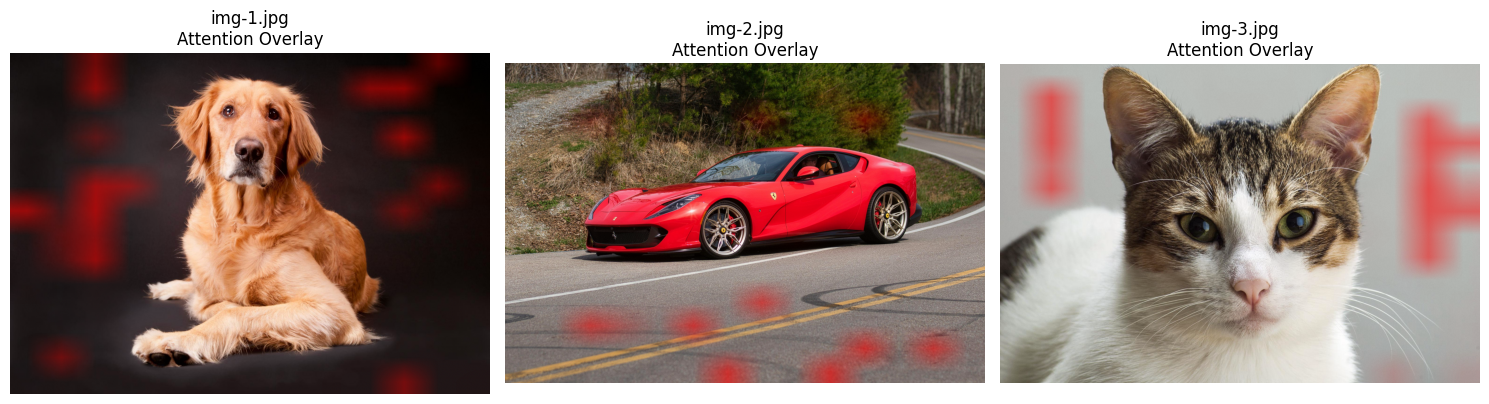

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def overlay_attention(image, attn_map, alpha=0.5, upscale_size=None):
    """
    image: PIL Image (RGB)
    attn_map: 2D torch tensor or numpy array (grid_size x grid_size)
    alpha: max opacity of the red overlay
    """
    if upscale_size is None:
        upscale_size = image.size  # (W, H)

    # Normalize attention map to [0, 1]
    attn = attn_map.clone().float()
    attn = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

    # Upsample to image resolution using bilinear interpolation
    attn = attn.unsqueeze(0).unsqueeze(0)  # (1, 1, grid, grid)
    attn_resized = F.interpolate(
        attn, size=(upscale_size[1], upscale_size[0]),  # (H, W)
        mode="bilinear", align_corners=False
    )
    attn_resized = attn_resized.squeeze().numpy()  # (H, W)

    # Build RGBA heatmap: red channel scaled by attention, alpha scaled by attention
    heatmap = np.zeros((upscale_size[1], upscale_size[0], 4))
    heatmap[..., 0] = 1.0          # Red
    heatmap[..., 1] = 0.0          # Green
    heatmap[..., 2] = 0.0          # Blue
    heatmap[..., 3] = attn_resized * alpha  # Alpha proportional to attention

    return np.array(image) / 255.0, heatmap


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, path) in enumerate(zip(axes, image_paths)):
    image = Image.open(path).convert("RGB")
    base_img, heatmap = overlay_attention(image, attn_maps[i], alpha=0.6)

    ax.imshow(base_img)
    ax.imshow(heatmap)
    ax.set_title(f"{path.split('/')[-1]}\nAttention Overlay")
    ax.axis("off")

print("Final Layer")
plt.tight_layout()
plt.show()

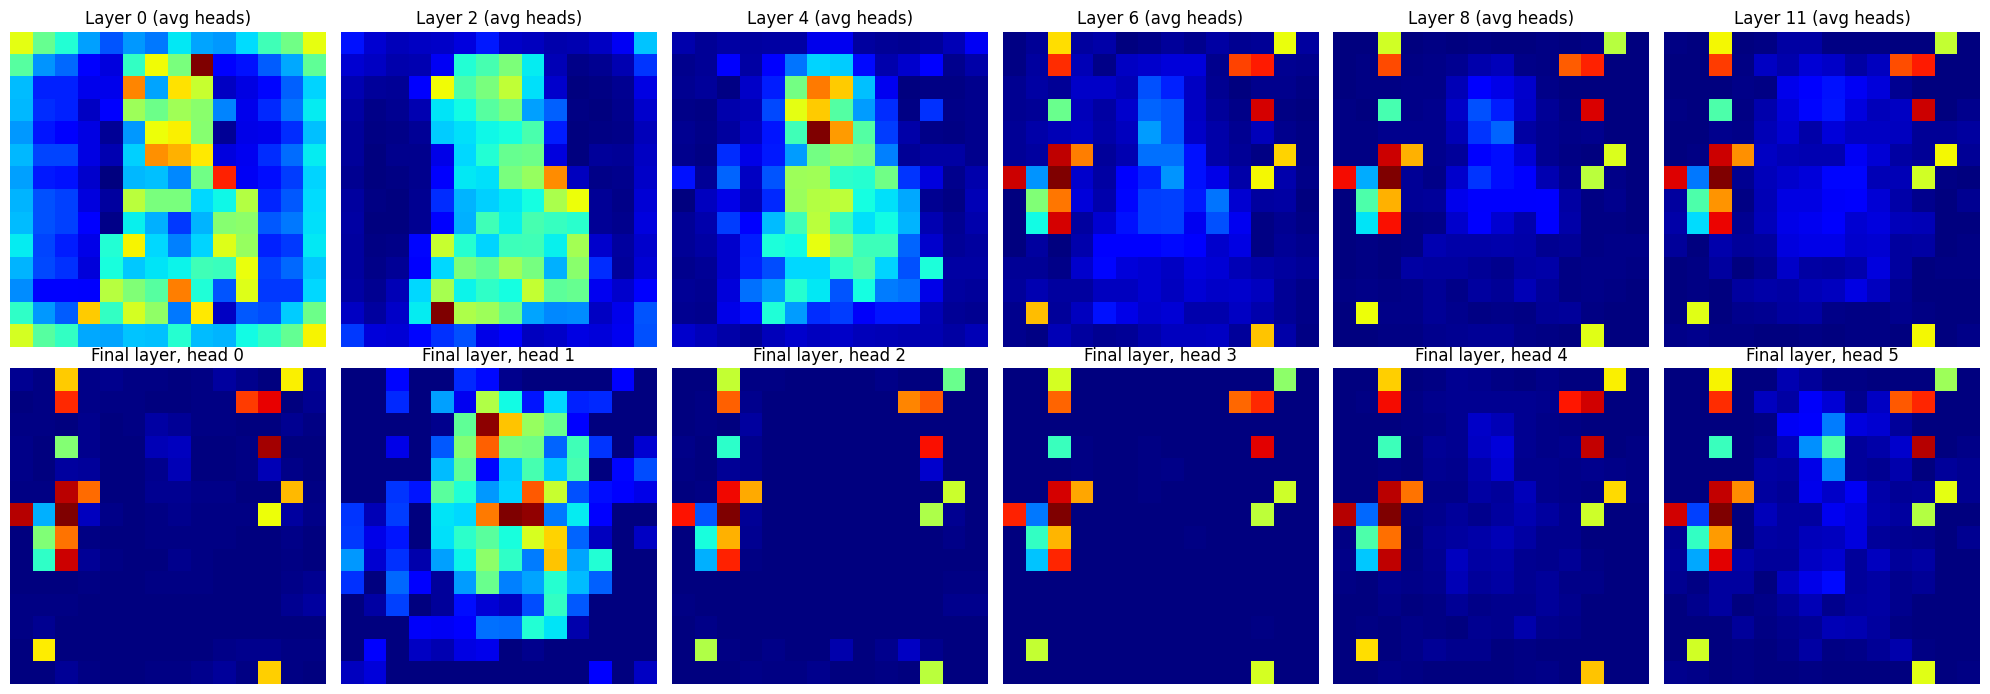

In [ ]:
img_idx = 0  # dog

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

# Row 1: average attention per layer (layers 0, 2, 4, 6, 8, 11)
layer_indices = [0, 2, 4, 6, 8, 11]
for col, layer_idx in enumerate(layer_indices):
    layer_attn = attentions[layer_idx][img_idx]  # (num_heads, seq_len, seq_len)
    avg_heads = layer_attn.mean(dim=0)            # (seq_len, seq_len)
    cls_to_patches = avg_heads[0, 1:]              # (196,)
    grid = cls_to_patches.reshape(14, 14).detach().numpy()
    axes[0, col].imshow(grid, cmap="jet")
    axes[0, col].set_title(f"Layer {layer_idx} (avg heads)")
    axes[0, col].axis("off")

# Row 2: individual heads in the FINAL layer
final_layer_attn = attentions[-1][img_idx]  # (num_heads, seq_len, seq_len)
for col in range(6):
    cls_to_patches = final_layer_attn[col, 0, 1:]
    grid = cls_to_patches.reshape(14, 14).detach().numpy()
    axes[1, col].imshow(grid, cmap="jet")
    axes[1, col].set_title(f"Final layer, head {col}")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

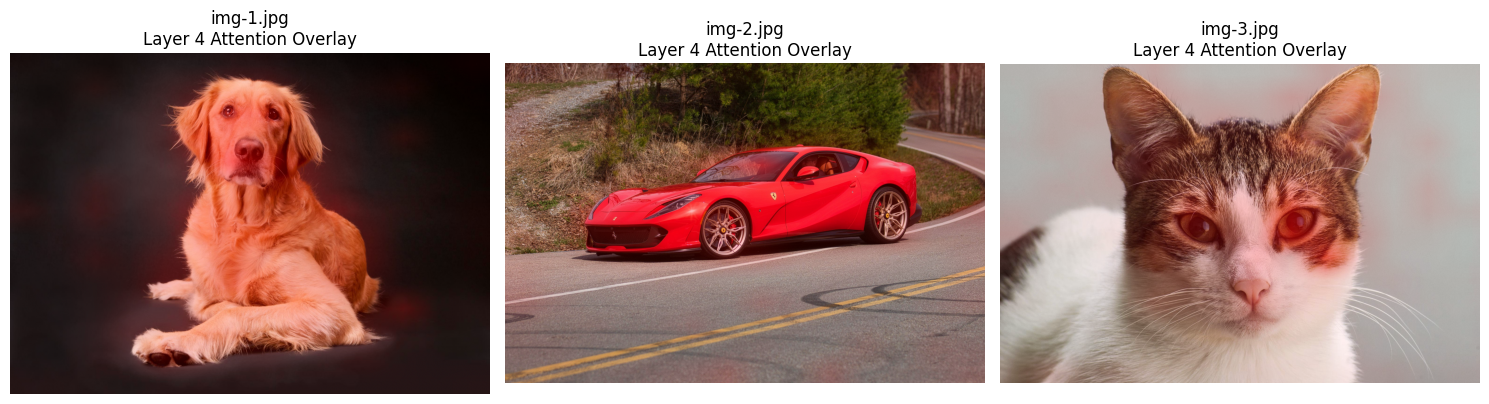

In [ ]:
# Use a middle layer instead of the final layer — avoids attention-sink corruption
layer_idx = 4

middle_layer_attn = attentions[layer_idx]          # (batch, num_heads, seq_len, seq_len)
avg_heads = middle_layer_attn.mean(dim=1)            # (batch, seq_len, seq_len)
cls_attn_mid = avg_heads[:, 0, 1:]                   # (batch, 196)
attn_maps_mid = cls_attn_mid.reshape(cls_attn_mid.shape[0], 14, 14)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (ax, path) in enumerate(zip(axes, image_paths)):
    image = Image.open(path).convert("RGB")
    base_img, heatmap = overlay_attention(image, attn_maps_mid[i], alpha=0.6)
    ax.imshow(base_img)
    ax.imshow(heatmap)
    ax.set_title(f"{path.split('/')[-1]}\nLayer {layer_idx} Attention Overlay")
    ax.axis("off")
plt.tight_layout()
plt.show()

3. Analyze the Attention Map:
Include the image containing the attention-map overlay and describe what you observe. Did the ViT focus on
image regions corresponding to the predicted object class?
For example, if the image contains a dog and the model predicts “dog,” determine whether the highlighted patches
outline the dog’s figure. This provides insight into whether the model is using appropriate visual features or
relying on the background or other contextual cues.
Conceptually compare the attention-based explanation with typical CNN interpretation methods such as CAM or
Grad-CAM. You do not need to implement CAM or Grad-CAM. Discuss the potential advantages of transformers
having built-in attention mechanisms for interpretability.
Note any unusual behavior, such as the model attending to an irrelevant region. Are different attention heads
specialized? Explain how you can determine whether specialization is occurring

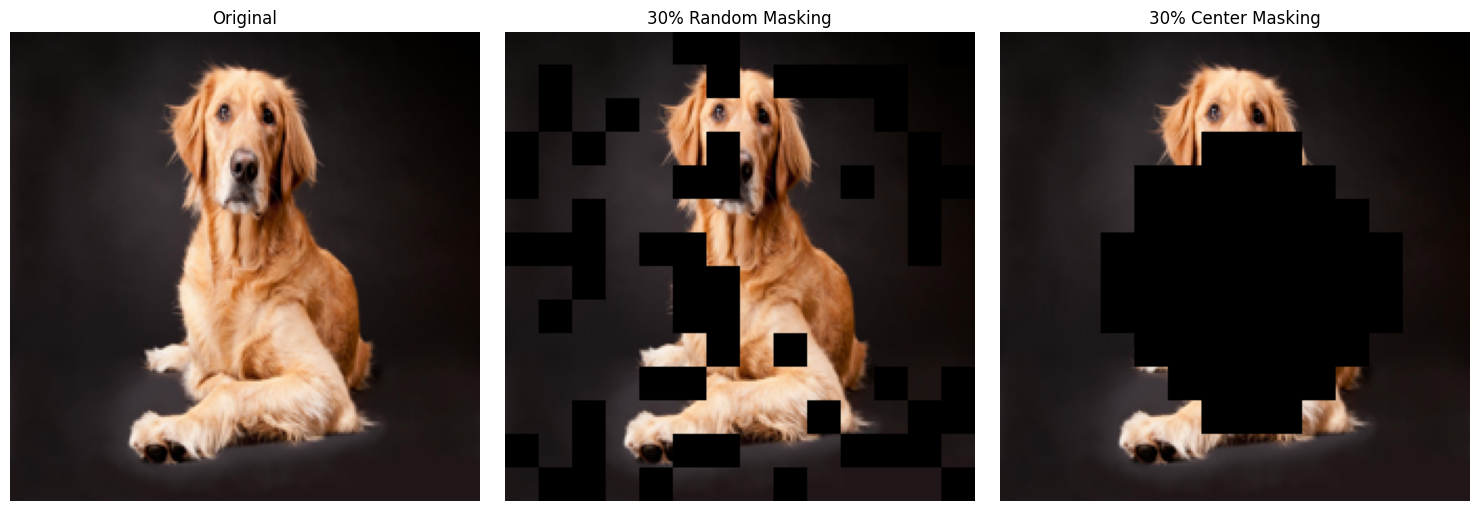

In [ ]:
import random

def mask_patches(image, patch_size=16, mask_fraction=0.3, mode="random", fill_value=0):
    """
    Mask a fraction of patches in a PIL image by replacing them with a fill color.

    image: PIL Image (RGB)
    patch_size: size of each square patch in pixels
    mask_fraction: fraction of patches to mask (0.0 - 1.0)
    mode: "random" or "center"
    fill_value: pixel value to fill masked patches with (0 = black)
    """
    img_array = np.array(image).copy()
    W, H = image.size
    n_patches_w = W // patch_size
    n_patches_h = H // patch_size
    total_patches = n_patches_w * n_patches_h
    n_mask = int(total_patches * mask_fraction)

    patch_coords = [(i, j) for i in range(n_patches_h) for j in range(n_patches_w)]

    if mode == "random":
        masked_coords = random.sample(patch_coords, n_mask)

    elif mode == "center":
        # Sort patches by distance from the center, mask the closest ones
        center_i, center_j = n_patches_h / 2, n_patches_w / 2
        patch_coords.sort(
            key=lambda c: (c[0] - center_i) ** 2 + (c[1] - center_j) ** 2
        )
        masked_coords = patch_coords[:n_mask]

    else:
        raise ValueError("mode must be 'random' or 'center'")

    for (i, j) in masked_coords:
        y0, y1 = i * patch_size, (i + 1) * patch_size
        x0, x1 = j * patch_size, (j + 1) * patch_size
        img_array[y0:y1, x0:x1] = fill_value

    return Image.fromarray(img_array), masked_coords


# Quick visual sanity check on one image
sample_image = Image.open(image_paths[0]).convert("RGB").resize((224, 224))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

masked_random, _ = mask_patches(sample_image, mask_fraction=0.3, mode="random")
masked_center, _ = mask_patches(sample_image, mask_fraction=0.3, mode="center")

axes[0].imshow(sample_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked_random)
axes[1].set_title("30% Random Masking")
axes[1].axis("off")

axes[2].imshow(masked_center)
axes[2].set_title("30% Center Masking")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def get_prediction(image, processor, model):
    """Run inference on a single PIL image, return predicted label + confidence."""
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred_idx = outputs.logits.argmax(dim=-1).item()
    label = model.config.id2label[pred_idx]
    confidence = probs[0, pred_idx].item()
    return label, confidence


mask_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

results = {"random": {}, "center": {}}

for path in image_paths:
    original_image = Image.open(path).convert("RGB").resize((224, 224))
    orig_label, orig_conf = get_prediction(original_image, processor, model)

    results["random"][path] = []
    results["center"][path] = []

    for frac in mask_fractions:
        if frac == 0.0:
            masked_random = original_image
            masked_center = original_image
        else:
            masked_random, _ = mask_patches(original_image, mask_fraction=frac, mode="random")
            masked_center, _ = mask_patches(original_image, mask_fraction=frac, mode="center")

        label_r, conf_r = get_prediction(masked_random, processor, model)
        label_c, conf_c = get_prediction(masked_center, processor, model)

        results["random"][path].append({
            "fraction": frac, "label": label_r, "confidence": conf_r,
            "correct": label_r == orig_label
        })
        results["center"][path].append({
            "fraction": frac, "label": label_c, "confidence": conf_c,
            "correct": label_c == orig_label
        })

    print(f"\n{path} — original prediction: {orig_label} ({orig_conf:.2%})")
    for frac_idx, frac in enumerate(mask_fractions):
        r = results["random"][path][frac_idx]
        c = results["center"][path][frac_idx]
        print(
            f"  {frac*100:>4.0f}% masked | "
            f"random: {r['label']:<25s} {r['confidence']:.2%}  |  "
            f"center: {c['label']:<25s} {c['confidence']:.2%} "
        )


img-1.jpg — original prediction: golden retriever (98.34%)
     0% masked | random: golden retriever          98.34%  |  center: golden retriever          98.34% 
    10% masked | random: golden retriever          98.57%  |  center: golden retriever          97.55% 
    20% masked | random: golden retriever          97.54%  |  center: golden retriever          87.18% 
    30% masked | random: golden retriever          97.98%  |  center: golden retriever          61.63% 
    40% masked | random: golden retriever          94.43%  |  center: golden retriever          42.82% 
    50% masked | random: golden retriever          97.29%  |  center: matchstick                47.89% 
    60% masked | random: golden retriever          58.36%  |  center: nematode, nematode worm, roundworm 11.16% 
    70% masked | random: golden retriever          94.77%  |  center: nematode, nematode worm, roundworm 3.53% 
    80% masked | random: golden retriever          7.02%  |  center: panpipe, pandean pipe,

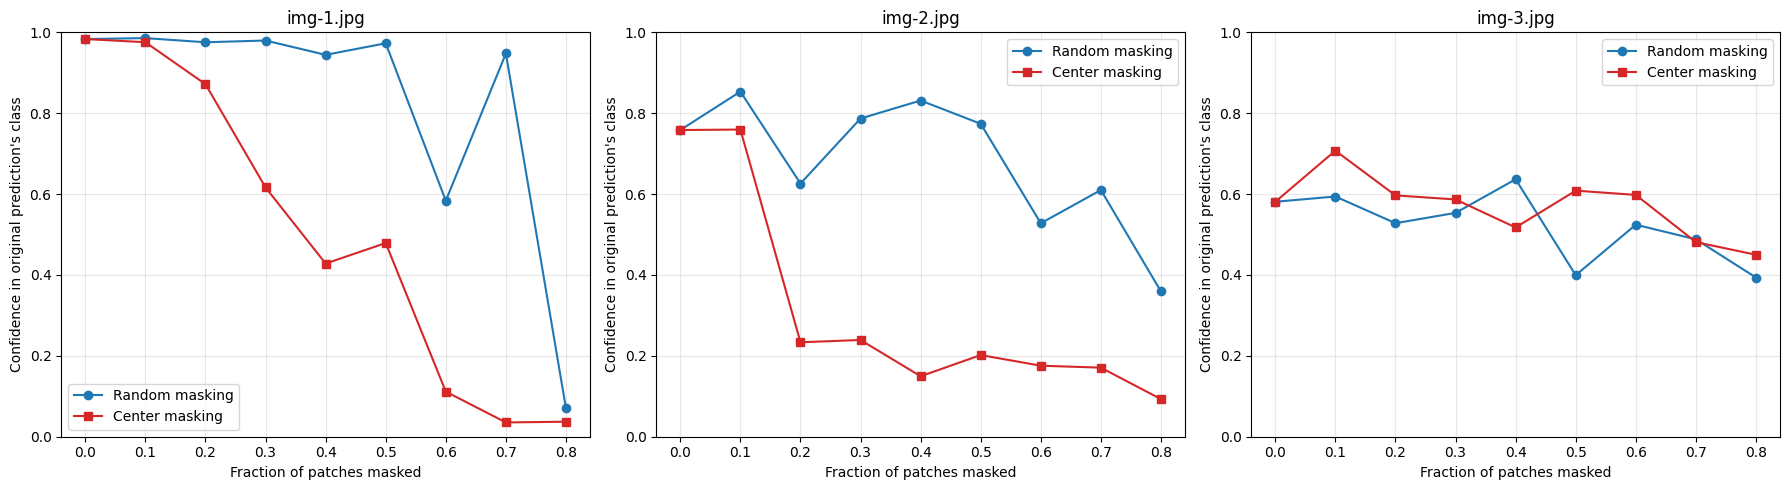

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, path in zip(axes, image_paths):
    fracs = [r["fraction"] for r in results["random"][path]]
    conf_random = [r["confidence"] for r in results["random"][path]]
    conf_center = [r["confidence"] for r in results["center"][path]]

    ax.plot(fracs, conf_random, marker="o", label="Random masking", color="tab:blue")
    ax.plot(fracs, conf_center, marker="s", label="Center masking", color="tab:red")
    ax.set_xlabel("Fraction of patches masked")
    ax.set_ylabel("Confidence in original prediction's class")
    ax.set_title(path.split("/")[-1])
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

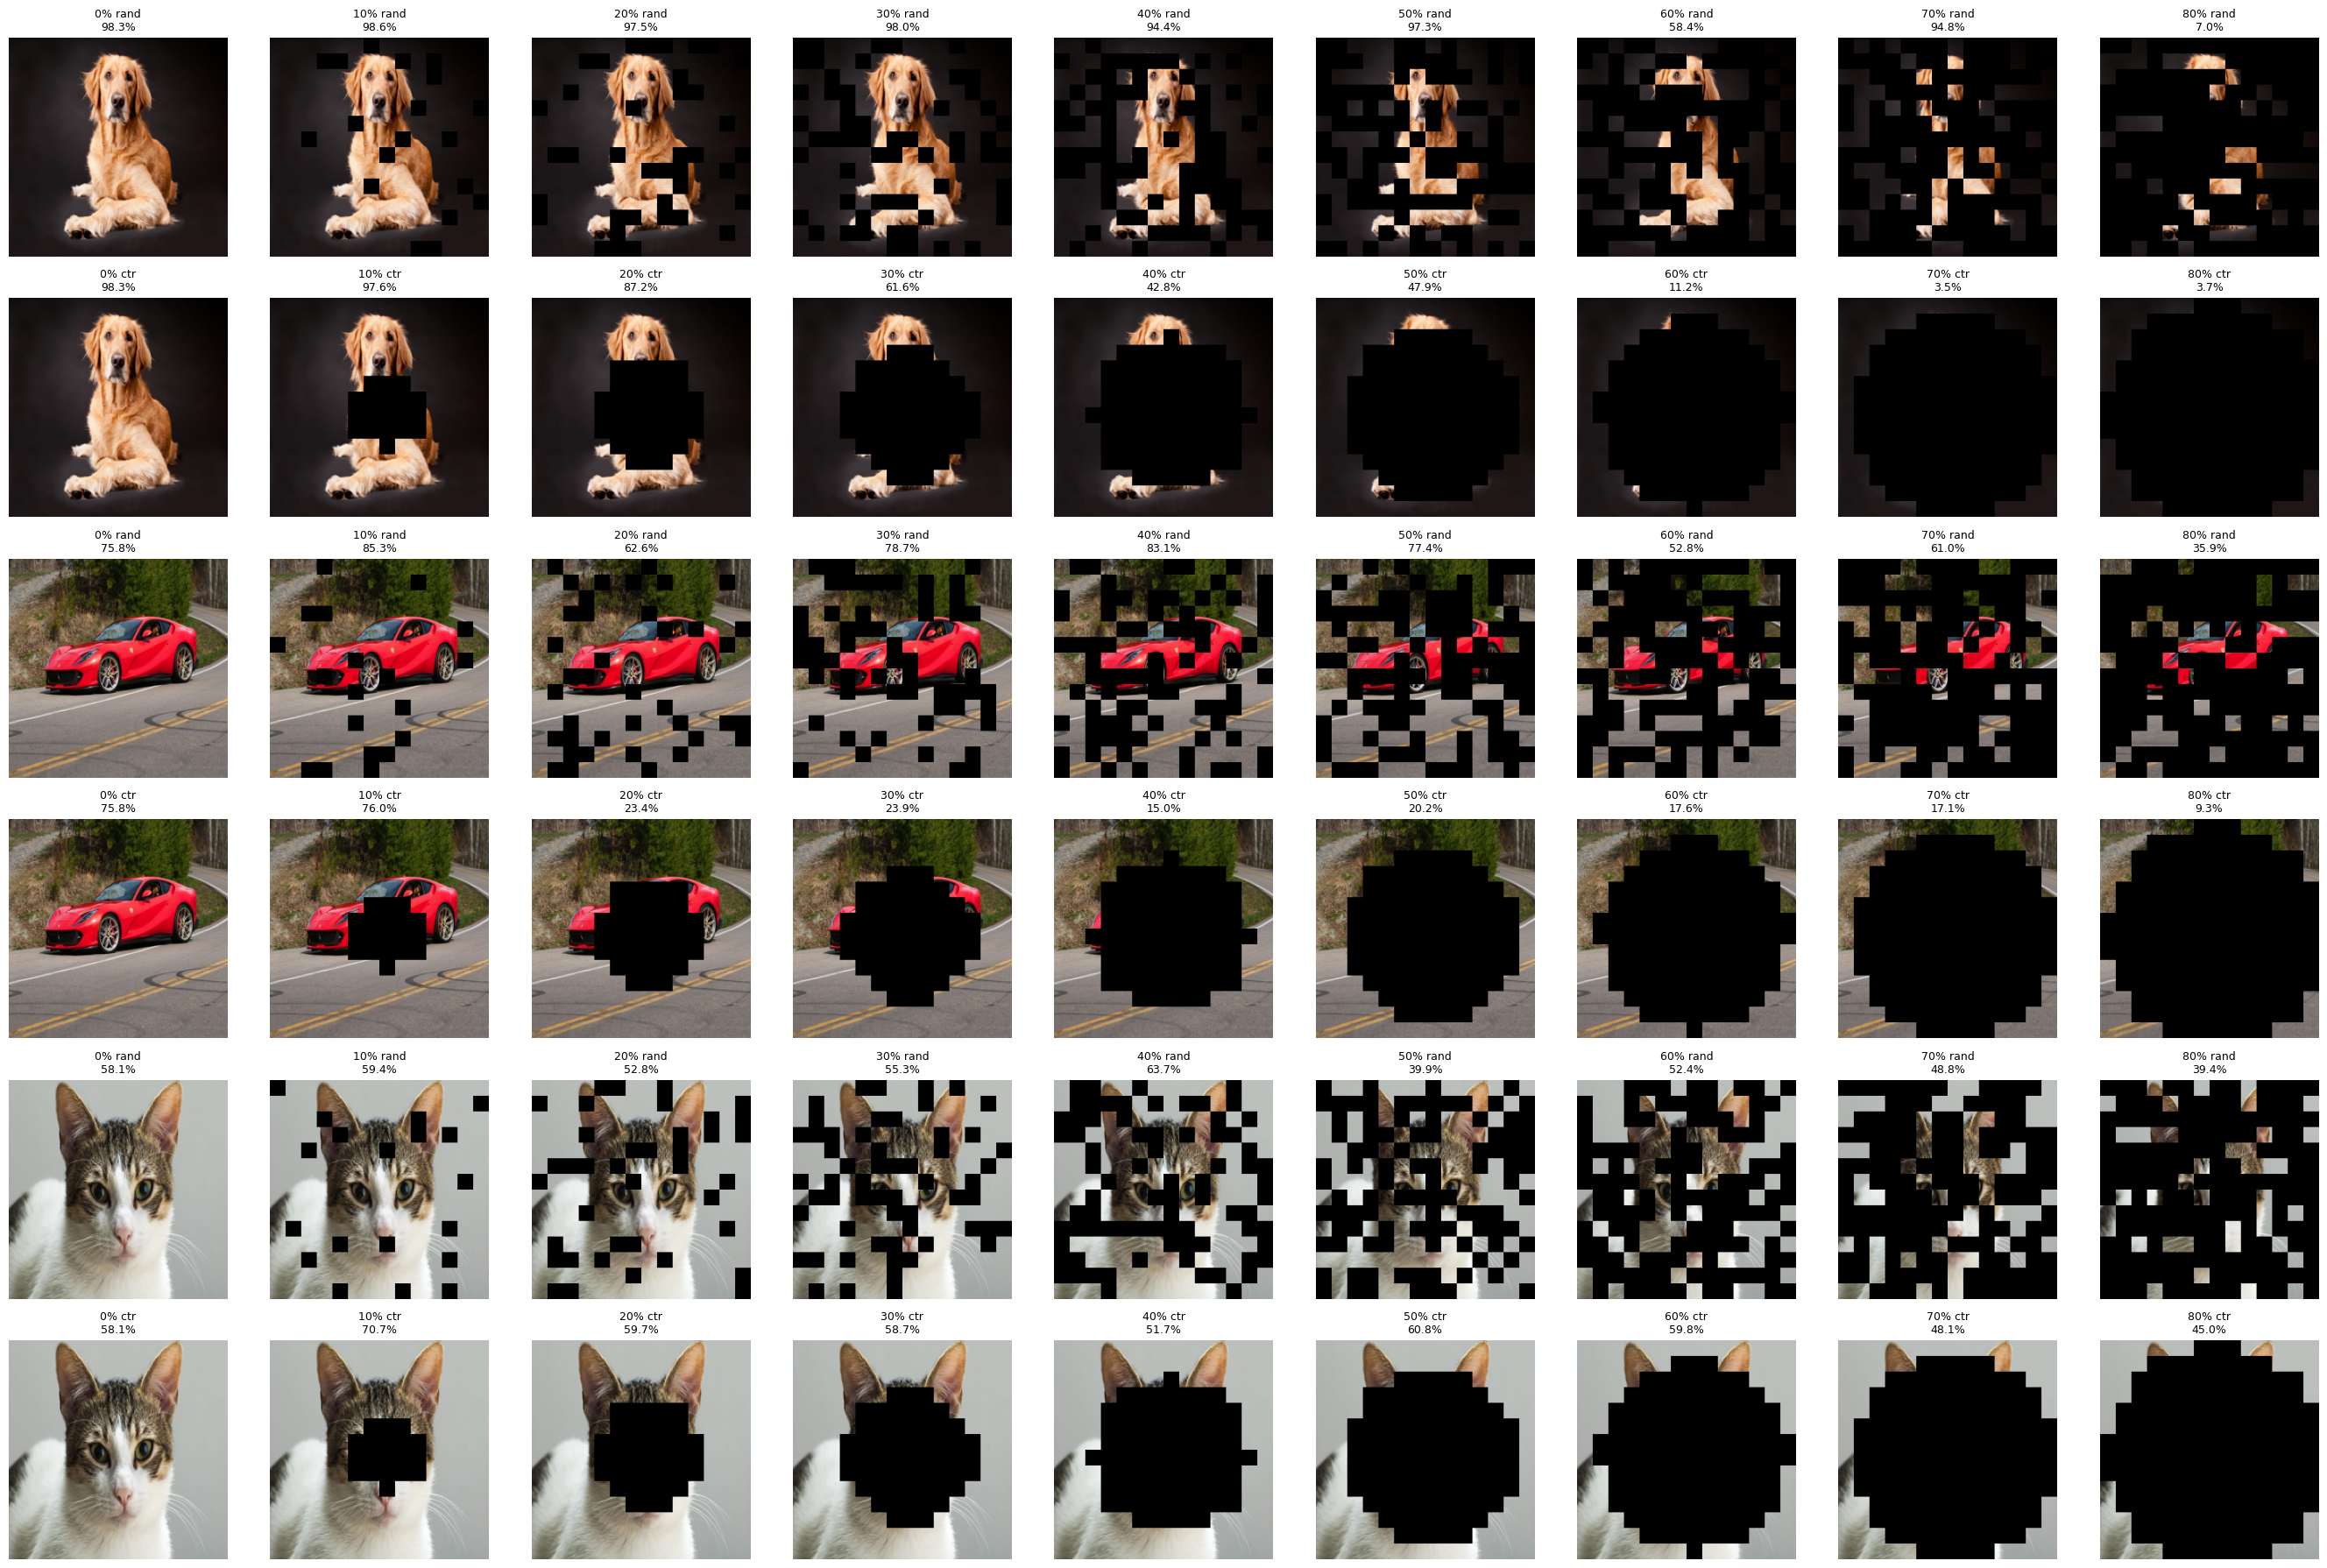

In [ ]:
fig, axes = plt.subplots(len(image_paths) * 2, len(mask_fractions), figsize=(3 * len(mask_fractions), 6 * len(image_paths)))

for row_pair, path in enumerate(image_paths):
    original_image = Image.open(path).convert("RGB").resize((224, 224))

    for col, frac in enumerate(mask_fractions):
        if frac == 0.0:
            m_random, m_center = original_image, original_image
        else:
            m_random, _ = mask_patches(original_image, mask_fraction=frac, mode="random")
            m_center, _ = mask_patches(original_image, mask_fraction=frac, mode="center")

        r_result = results["random"][path][col]
        c_result = results["center"][path][col]

        ax_r = axes[row_pair * 2, col]
        ax_r.imshow(m_random)
        ax_r.set_title(f"{frac*100:.0f}% rand\n{r_result['confidence']:.1%}", fontsize=9)
        ax_r.axis("off")

        ax_c = axes[row_pair * 2 + 1, col]
        ax_c.imshow(m_center)
        ax_c.set_title(f"{frac*100:.0f}% ctr\n{c_result['confidence']:.1%}", fontsize=9)
        ax_c.axis("off")

plt.tight_layout()
plt.show()

first check the code and then run

In [ ]:
# Feature extraction: get both CLS token and mean-pooled patch token representations
# We need hidden_states from the base ViTModel (not just logits), so use output_hidden_states
# or better, use the ViTModel backbone directly to get the full sequence output

from transformers import ViTModel

backbone = ViTModel.from_pretrained(model_name, attn_implementation="eager")
backbone.eval()

def extract_features(images, processor, backbone, batch_size=32):
    """
    Returns:
        cls_features: (N, hidden_dim) - the [CLS] token's final hidden state
        mean_features: (N, hidden_dim) - mean over all patch tokens' final hidden states
    """
    cls_features_list = []
    mean_features_list = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        inputs = processor(images=batch, return_tensors="pt")

        with torch.no_grad():
            outputs = backbone(**inputs)

        last_hidden = outputs.last_hidden_state  # (batch, seq_len, hidden_dim)

        cls_token = last_hidden[:, 0, :]          # (batch, hidden_dim)
        patch_tokens = last_hidden[:, 1:, :]      # (batch, num_patches, hidden_dim)
        mean_patch = patch_tokens.mean(dim=1)     # (batch, hidden_dim)

        cls_features_list.append(cls_token)
        mean_features_list.append(mean_patch)

        print(f"Processed {min(i + batch_size, len(images))}/{len(images)}")

    return torch.cat(cls_features_list, dim=0), torch.cat(mean_features_list, dim=0)

In [ ]:
import torchvision
from torchvision.datasets import CIFAR10

# Download a small subset of CIFAR-10 for the linear probe experiment
# (using a subset to keep feature extraction fast on CPU)
train_dataset = CIFAR10(root="./data", train=True, download=True)
test_dataset = CIFAR10(root="./data", train=False, download=True)

# Subsample for speed — e.g. 200 per class for train, 50 per class for test
def subsample_by_class(dataset, n_per_class, num_classes=10):
    class_counts = {c: 0 for c in range(num_classes)}
    indices = []
    for idx, (_, label) in enumerate(dataset):
        if class_counts[label] < n_per_class:
            indices.append(idx)
            class_counts[label] += 1
        if all(c >= n_per_class for c in class_counts.values()):
            break
    return indices

train_indices = subsample_by_class(train_dataset, n_per_class=100)
test_indices = subsample_by_class(test_dataset, n_per_class=30)

train_images = [train_dataset[i][0].convert("RGB") for i in train_indices]
train_labels = [train_dataset[i][1] for i in train_indices]

test_images = [test_dataset[i][0].convert("RGB") for i in test_indices]
test_labels = [test_dataset[i][1] for i in test_indices]

print(f"Train set: {len(train_images)} images")
print(f"Test set: {len(test_images)} images")

100%|██████████| 170M/170M [17:00<00:00, 167kB/s]


Train set: 1000 images
Test set: 300 images


In [ ]:
# Extract features for train and test sets
print("Extracting training features...")
train_cls_feats, train_mean_feats = extract_features(train_images, processor, backbone)

print("\nExtracting test features...")
test_cls_feats, test_mean_feats = extract_features(test_images, processor, backbone)

print(f"\nCLS features shape: {train_cls_feats.shape}")
print(f"Mean-pooled features shape: {train_mean_feats.shape}")

Extracting training features...
Processed 32/1000
Processed 64/1000
Processed 96/1000
Processed 128/1000
Processed 160/1000
Processed 192/1000
Processed 224/1000
Processed 256/1000
Processed 288/1000
Processed 320/1000
Processed 352/1000
Processed 384/1000
Processed 416/1000
Processed 448/1000
Processed 480/1000
Processed 512/1000
Processed 544/1000
Processed 576/1000
Processed 608/1000
Processed 640/1000
Processed 672/1000
Processed 704/1000
Processed 736/1000
Processed 768/1000
Processed 800/1000
Processed 832/1000
Processed 864/1000
Processed 896/1000
Processed 928/1000
Processed 960/1000
Processed 992/1000
Processed 1000/1000

Extracting test features...
Processed 32/300
Processed 64/300
Processed 96/300
Processed 128/300
Processed 160/300
Processed 192/300
Processed 224/300
Processed 256/300
Processed 288/300
Processed 300/300

CLS features shape: torch.Size([1000, 768])
Mean-pooled features shape: torch.Size([1000, 768])


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

def train_and_eval_probe(train_feats, train_labels, test_feats, test_labels, name):
    """Train a linear probe (logistic regression) and evaluate on test set."""
    train_feats_np = train_feats.numpy()
    test_feats_np = test_feats.numpy()

    # Standardize features — helps linear probe convergence and fairness of comparison
    scaler = StandardScaler()
    train_feats_scaled = scaler.fit_transform(train_feats_np)
    test_feats_scaled = scaler.transform(test_feats_np)

    probe = LogisticRegression(max_iter=2000, multi_class="multinomial")
    probe.fit(train_feats_scaled, train_labels)

    train_preds = probe.predict(train_feats_scaled)
    test_preds = probe.predict(test_feats_scaled)

    train_acc = accuracy_score(train_labels, train_preds)
    test_acc = accuracy_score(test_labels, test_preds)

    print(f"\n=== {name} ===")
    print(f"Train accuracy: {train_acc:.2%}")
    print(f"Test accuracy:  {test_acc:.2%}")

    return probe, train_acc, test_acc


cls_probe, cls_train_acc, cls_test_acc = train_and_eval_probe(
    train_cls_feats, train_labels, test_cls_feats, test_labels, "CLS Token Probe"
)

mean_probe, mean_train_acc, mean_test_acc = train_and_eval_probe(
    train_mean_feats, train_labels, test_mean_feats, test_labels, "Mean Patch-Pooling Probe"
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== CLS Token Probe ===
Train accuracy: 100.00%
Test accuracy:  95.67%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Mean Patch-Pooling Probe ===
Train accuracy: 100.00%
Test accuracy:  95.33%


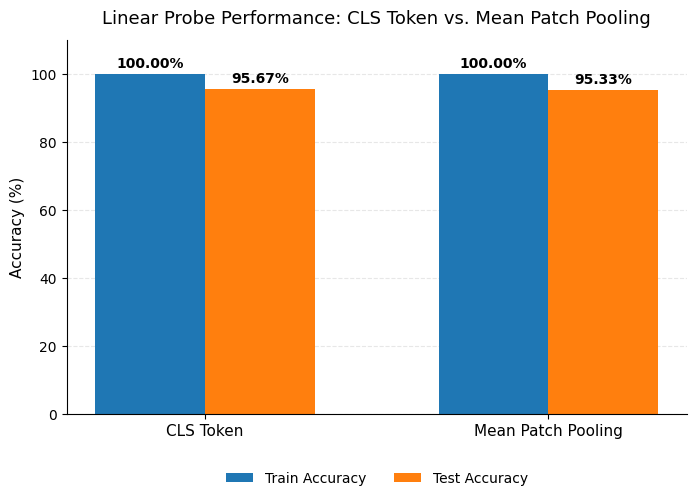

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["CLS Token", "Mean Patch Pooling"]

train_accs = [cls_train_acc * 100, mean_train_acc * 100]
test_accs  = [cls_test_acc * 100, mean_test_acc * 100]

x = np.arange(len(methods))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5.5))

bars_train = ax.bar(
    x - width / 2,
    train_accs,
    width,
    label="Train Accuracy"
)

bars_test = ax.bar(
    x + width / 2,
    test_accs,
    width,
    label="Test Accuracy"
)

# Value labels
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.0,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Labels
ax.set_ylabel("Accuracy (%)", fontsize=11)

ax.set_title(
    "Linear Probe Performance: CLS Token vs. Mean Patch Pooling",
    fontsize=13,
    pad=12
)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)

# Y-axis
ax.set_ylim(0, 110)
ax.set_yticks(np.arange(0, 101, 20))

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend BELOW the plot, completely outside the axes
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

# Make room for the legend
plt.subplots_adjust(
    top=0.88,
    bottom=0.20
)

plt.show()